# **Basic Model Notebook Overview**

*Pipeline of setting up, building, training, testing, analyzing, my basic model*

---

In [1]:
import os
import torch
import pandas as pd
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sqlalchemy import create_engine
from dotenv import load_dotenv
import pickle

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

import sys
sys.path.insert(0, '../..')

from modeling.dataset import CarPriceDataset
from modeling.model import MLPCarPriceRegressionNet_V1, MLPCarPriceRegressionNet_V2
from modeling.train import train_model
from modeling.test import test_model
from modeling.plots_and_metrics import train_plot,train_metrics, test_plot, test_metrics
from modeling.plots_and_metrics import plot_outlier_years, plot_outlier_km, plot_outlier_price, plot_outlier_by_manufacturer, plot_outlier_by_kw

from preprocessing.preprocess import PreProcessor
from preprocessing.clean import Cleaner
from preprocessing.impute import Imputer
from preprocessing.engineer import Engineer 


## **Cleaning & PreProcessing Pipeline**

In this basic model:

- Car price: 200k - 100M
- Car year: 2000 - 

---

In [2]:
FILENAME = 'car_details.csv'

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

df = pd.read_csv(f'../../data/raw/{FILENAME}')

cleaner = Cleaner(price_lower=200_000, price_upper = 100_000_000, year_lower = 2000, year_upper = None)
imputer = Imputer()
engineer = Engineer()

df = cleaner.clean(df)
summary = cleaner.get_summary()
display(summary)

df = imputer.impute(df)
summary = imputer.get_summary()
display(summary)

df = engineer.transform(df)
summary = engineer.get_summary()
display(summary)

df.to_csv(f'../../data/clean/car_details_basic.csv', index=False)

,Feature,Length Before,Length After,Dropped
0,Price,106447,104697,1750
1,Year,104697,100474,4223
2,Manufacturer/Model,100474,100326,148
3,Kilometers,100326,100304,22
4,Fuel Type,100304,100304,0
5,KW/LE,100304,98966,1338
6,Condition,98966,98966,0
7,Trunk Capacity,98966,98959,7
8,Body Type,98959,98956,3
9,Seats,98956,98951,5


,Feature,Missing Before,Missing After,Imputed
0,Kilometers,1676,0,1676
1,Fuel Type,706,0,706
2,Trunk Capacity,10189,0,10189
3,Seats,1249,0,1249
4,Color,21573,0,21573
5,Engine Capacity,392,0,392
6,Drive Type,2261,0,2261
7,Transmission Type,3881,0,3881
8,Number of Gears,18107,0,18107


,Feature,Unqiue Before,Unqiue After
0,Fuel Type,14,7
1,Transmission Type,10,6
2,Color,76,38


## **Data Prep**

Includes:

- Splitting into train/val/test ~ 80/10/10 ratio
- Scaling & Encoding = fitting on only training set with PreProcessor
    - saved config
    - there is a human readable json config also, if debug needed
    - final numerical features, their scaler (type)
    - final categorical, their unique values, vocab size for future embeddings
- Model setup:
    - went for a wide but not too deep setup
        - input layer (around 80 neurons) -> 256
        - 2 hidden layers
        - output layer
    - activation function:
        - relu
    - no batchnorm
    - 0.2, 0.1 dropout in hidden layers
- Wrapping in datasets & dataloaders

---


In [3]:
df_train, df_temp = train_test_split(df, test_size = 0.2, random_state = 1)
df_val, df_test = train_test_split(df_temp, test_size = 0.5, random_state = 1)

preprocessor = PreProcessor()
preprocessor.fit(df_train)
preprocessor.save('../../workspace/config/basic_model.pkl', '../../workspace/config/basic_model.json')

model = MLPCarPriceRegressionNet_V2('../../workspace/config/basic_model.pkl')

X_num_train, X_cat_train, y_train = preprocessor.transform(df_train, is_training = True, include_target = True)
X_num_val, X_cat_val, y_val = preprocessor.transform(df_val, is_training = False, include_target = True)
X_num_test, X_cat_test, y_test = preprocessor.transform(df_test, is_training = False, include_target = True)

train_dataset = CarPriceDataset(X_num_train, X_cat_train, y_train)
val_dataset = CarPriceDataset(X_num_val, X_cat_val, y_val)
test_dataset = CarPriceDataset(X_num_test, X_cat_test, y_test)

batch_size = 64

dataloader_train = DataLoader(dataset = train_dataset, batch_size = batch_size, shuffle = True)
dataloader_val = DataLoader(dataset = val_dataset, batch_size = batch_size, shuffle = True)
dataloader_test = DataLoader(dataset = test_dataset, batch_size = batch_size, shuffle = False)

## **Training & Plotting training**

Model training extras:

- learning rate scheduling
- early stopping
- gradient clipping

---

Training on: cpu

Epoch [1/100] (LR: 0.000500)
  Train Loss: 6.5634
  Val Loss:   0.1691
  Val MAPE:   33.09%

Epoch [2/100] (LR: 0.000500)
  Train Loss: 0.7247
  Val Loss:   0.3963
  Val MAPE:   40.15%
  Early stopping counter: 1/40

Epoch [3/100] (LR: 0.000500)
  Train Loss: 0.4856
  Val Loss:   0.1282
  Val MAPE:   25.54%

Epoch [4/100] (LR: 0.000500)
  Train Loss: 0.3241
  Val Loss:   0.1346
  Val MAPE:   25.83%
  Early stopping counter: 1/40

Epoch [5/100] (LR: 0.000500)
  Train Loss: 0.2399
  Val Loss:   0.0990
  Val MAPE:   27.53%

Epoch [6/100] (LR: 0.000500)
  Train Loss: 0.1807
  Val Loss:   0.0691
  Val MAPE:   20.71%

Epoch [7/100] (LR: 0.000500)
  Train Loss: 0.1290
  Val Loss:   0.0658
  Val MAPE:   19.41%

Epoch [8/100] (LR: 0.000500)
  Train Loss: 0.1040
  Val Loss:   0.0770
  Val MAPE:   24.14%
  Early stopping counter: 1/40

Epoch [9/100] (LR: 0.000500)
  Train Loss: 0.0907
  Val Loss:   0.1190
  Val MAPE:   24.87%
  Early stopping counter: 2/40

Epoch [10/100] (LR: 0

Metric,Value
BEST EPOCH,55.000000
BEST VAL LOSS,0.047862


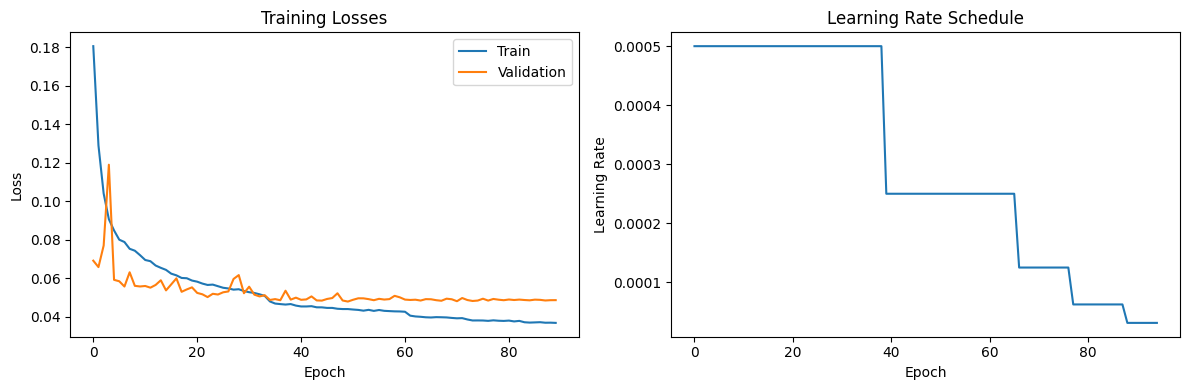

In [4]:
train = True

if train == True:
    history, model = train_model(
        model=model,
        train_loader=dataloader_train,
        val_loader=dataloader_val,
        epochs=100,
        learning_rate=0.0005,
        learning_rate_decay_factor=0.5
    )
    with open('../../workspace/train_histories/basic_model.pkl', 'wb') as f:
        pickle.dump(history, f)
    torch.save(model.state_dict(), '../../workspace/models/basic_model.pt')

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

with open('../../workspace/train_histories/basic_model.pkl', 'rb') as f:
    history = pickle.load(f)

display(train_metrics(history=history).style.hide(axis=0))
train_plot(history=history, skip_first_x=5)


## **Testing & Plotting**

- Displaying more interpretable values
- visualizing MAPE 

Metric,Value,Description
MAE,0.97M Ft,Average absolute error
RMSE,2.32M Ft,Root mean squared error ~ penalizes outliers more
Mean APE,16.54%,Mean absolute percentage error ~ %
Median APE,10.87%,Median absolute percentage error ~ %
Within 10%,46.86%,Predictions with < 10% error
Within 20%,75.05%,Predictions with < 20% error
Within 30%,87.55%,Predictions with < 30% error


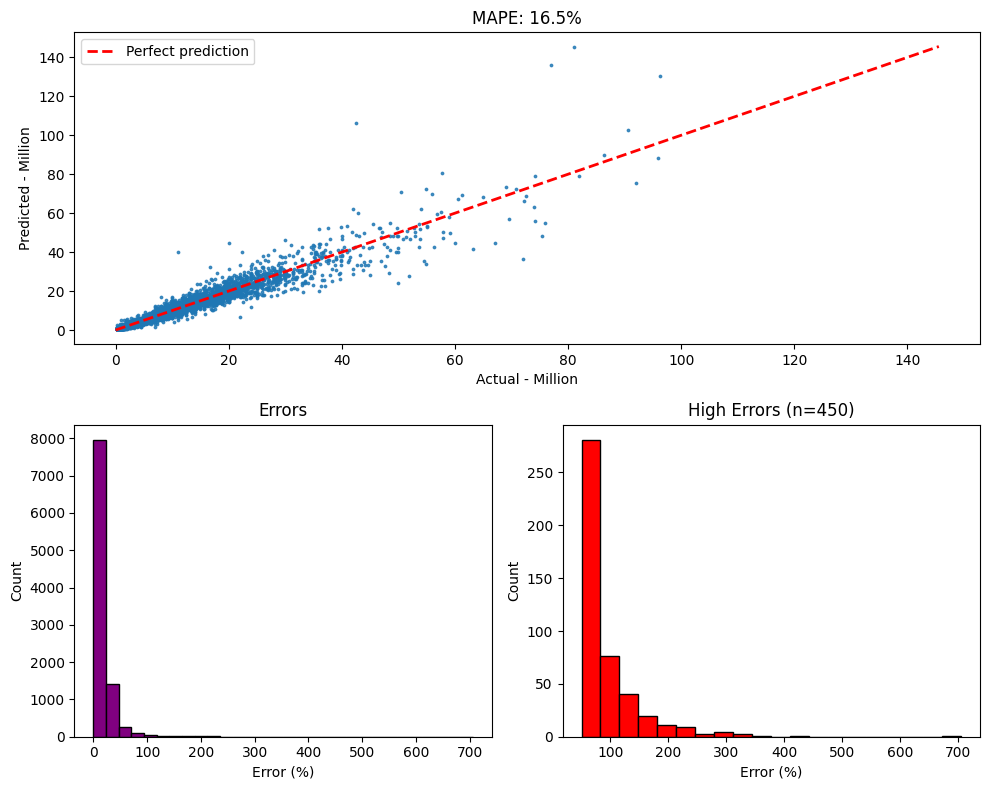

In [5]:
model.load_state_dict(torch.load('../../workspace/models/basic_model.pt'))

results = test_model(model, dataloader_test)
''' results = {
        'actual_prices' : actual_prices,
        'prediction_prices' : pred_prices,
        'percent_errors' : percent_errors,
        'metrics' : {
            'mae': mae,
            'rmse': rmse,
            'mape': mape,
            'median_ape': median_ape,
            'within_10': within_10,
            'within_20': within_20,
            'within_30': within_30
        }
    }
'''
display(test_metrics(results = results).style.hide(axis=0))
test_plot(results = results)

## **Thoughts & Outlier searching**

- While 16-17% MAPE isn't bad it's not really great either in my opinion

- I want to further improve the model by searching for which feature causes the most amount of outliers -> making / tuning a model accordingly for the lowest amount of mse loss and mape

- Plots:
    - All of the plots have a similar theme, besides the manufacturer plot
    - First one shows the number of outliers in a certain range of the feature which can be misleading given we can't see the whole sample size in respect to the number of outliers *(and the sample distribution is not the same in each range)*
    - Second plot is more important because it shows what is the chance of a car being an outlier in a certain range of a feature
---

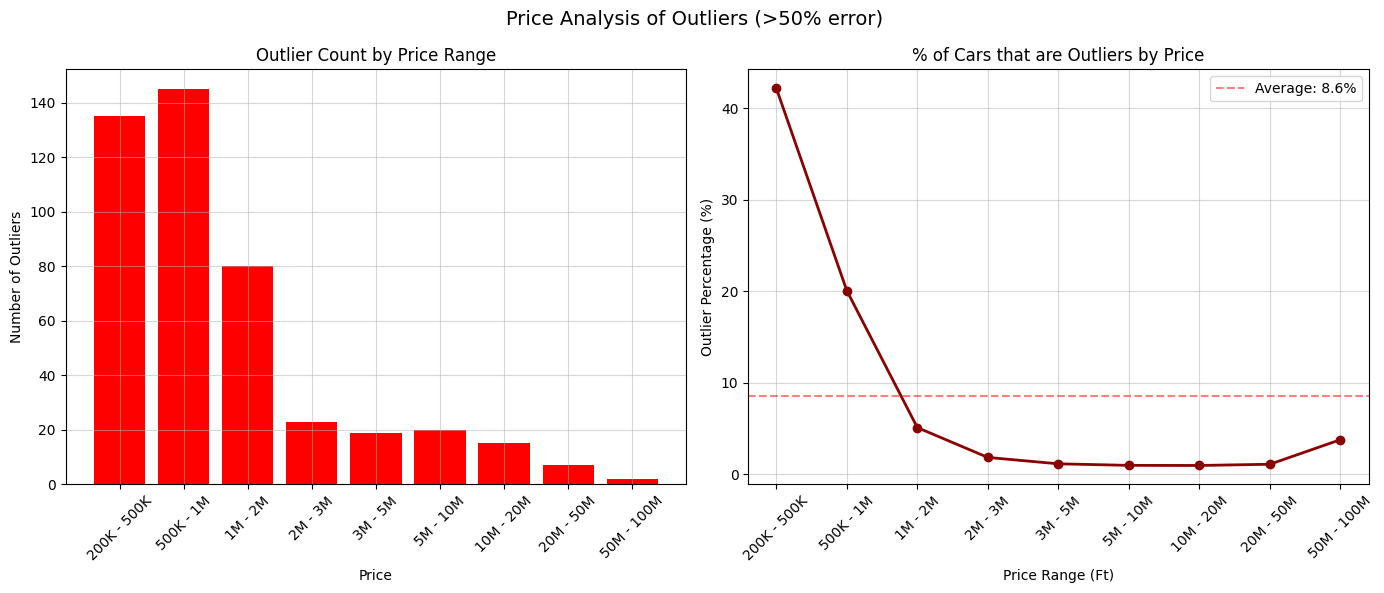

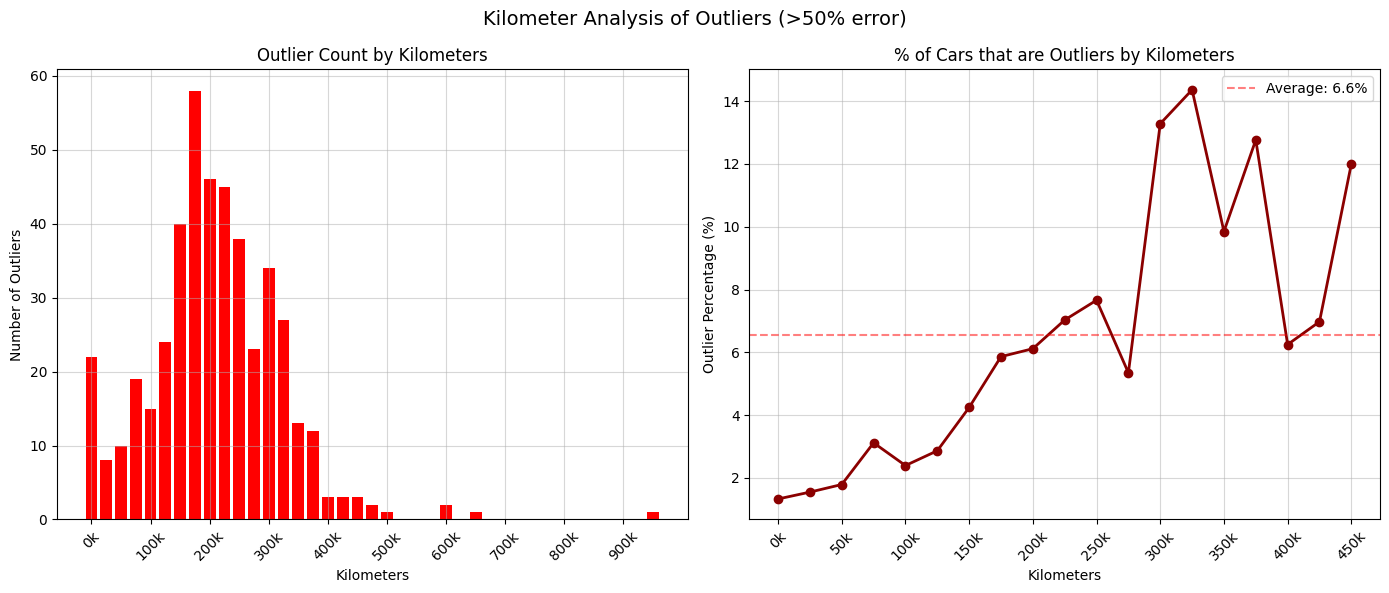

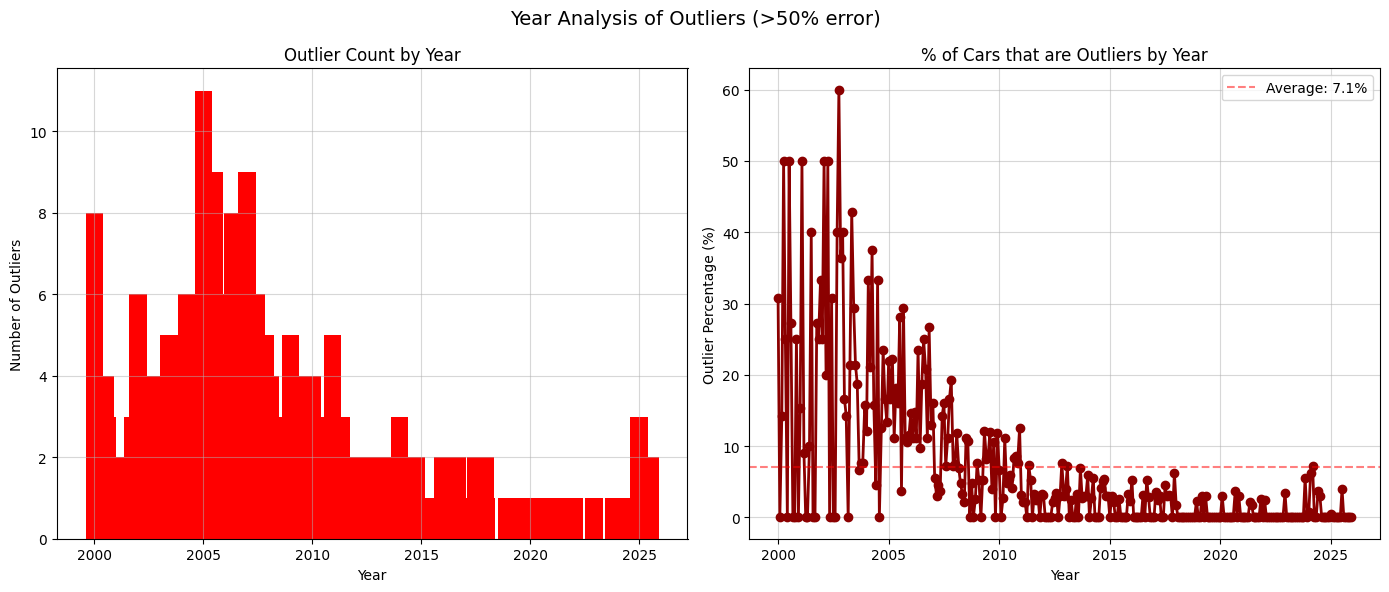

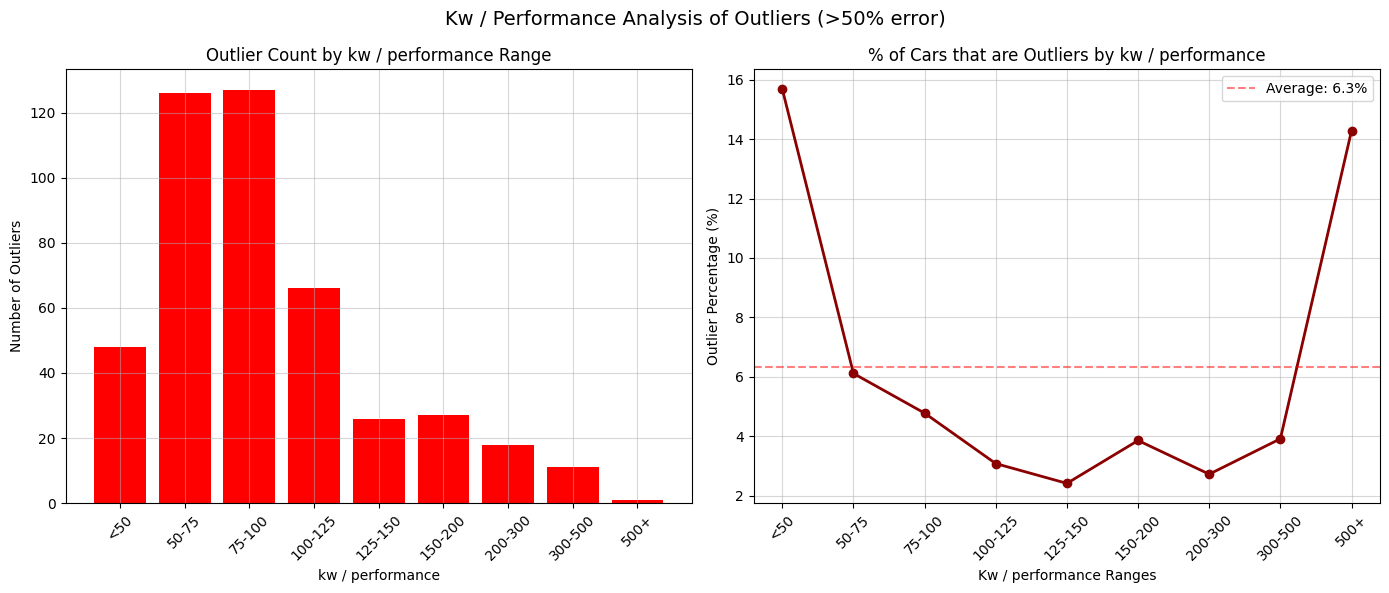

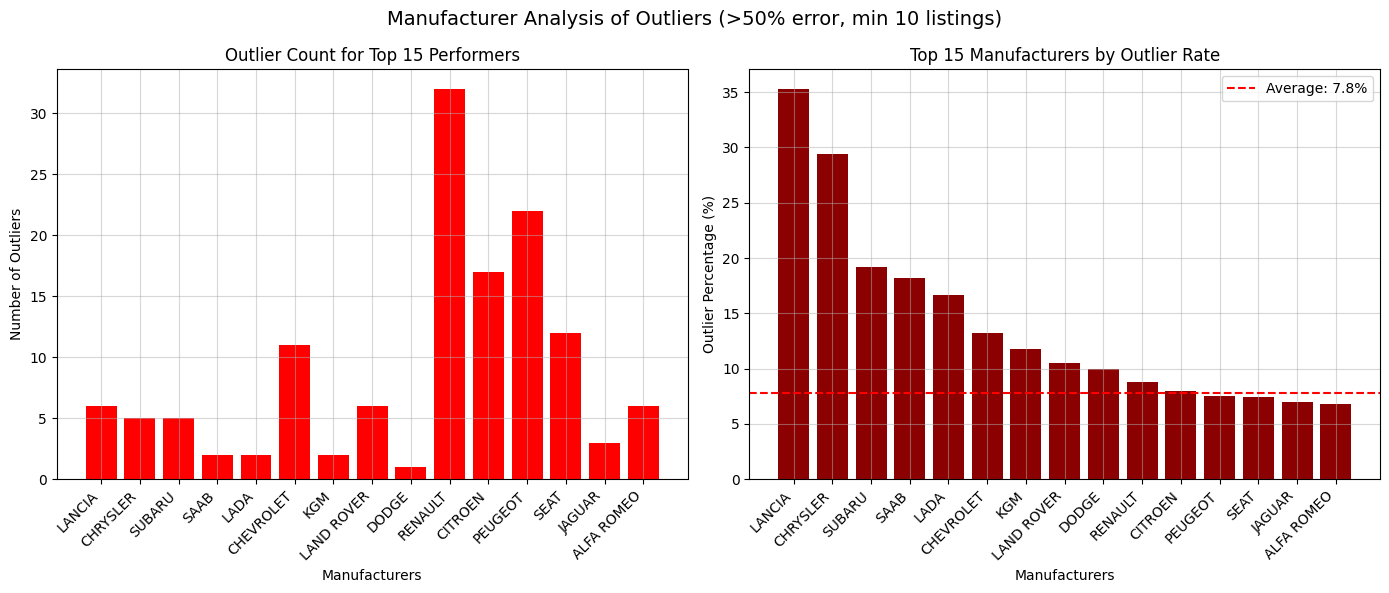

In [6]:
plot_outlier_price(results = results, df_test = df_test, threshold = 50)
plot_outlier_km(results = results, df_test = df_test, threshold = 50)
plot_outlier_years(results = results, df_test = df_test, threshold = 50)
plot_outlier_by_kw(results = results, df_test = df_test, threshold = 50)
plot_outlier_by_manufacturer(results = results, df_test = df_test, threshold = 50, min_listings = 10)

## **Final Thoughts & Plans**

Some of the plots really showed what is exactly wrong with my model

- the price plot, year plot, performance plot ~ they are probably all in connection with each other though
- basically my model performs really poor on cars before 2010 and under 1 million price range
- probably in this budget range the condition matters more or the less kilometer, also some could be vintage cars?
    
Ways I can go for:
- Probably give more importance to age when making a prediction by making an age^2 feature or
- Engineer 'age x condition', 'age x kilometer' etc features
- Make seperate models for budget class cars
- Just drop budget class alltogether

Plan:
- In order to maximize models performance and minimize loss and mape ill just go for 2010 and later cars and over 1M cars
- Probably most of car buyers are looking for this range 
- Probably will need another model architecture because of the loss of sample size, mainly fewer hidden layers
